# Information Presentation & Data Visualisation

## 11 Lab Exercise sheet: Visualisation for machine learning

In this lab, you will apply various visualisation techniques to real-world datasets for machine learning applications.

## Task 1: Data loading and preprocessing

Dataset: Use a real world dataset of your own choice. 

1) Load the dataset.

2) Handle missing values (drop or impute appropriately).

3) Encode categorical variables.

4) Transform numerical features if needed.

In [772]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, label_binarize, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score

In [731]:
# Task 1: Data loading and preprocessing

# Load dataset
df = pd.read_csv("car_sales_data.csv")
print("✅ Dataset loaded successfully!")
print(df.head(), "\n")

✅ Dataset loaded successfully!
  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101   



In [732]:
# Handle missing values (drop rows with missing data)
print(df.isnull().sum(), "\n")

df.dropna(inplace=True)
print("✅ Missing values handled:")
print(df.head(), "\n")

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64 

✅ Missing values handled:
  Manufacturer       Model  Engine size Fuel type  Year of manufacture  \
0         Ford      Fiesta          1.0    Petrol                 2002   
1      Porsche  718 Cayman          4.0    Petrol                 2016   
2         Ford      Mondeo          1.6    Diesel                 2014   
3       Toyota        RAV4          1.8    Hybrid                 1988   
4           VW        Polo          1.0    Petrol                 2006   

   Mileage  Price  
0   127300   3074  
1    57850  49704  
2    39190  24072  
3   210814   1705  
4   127869   4101   



In [733]:
# Encode categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns
for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])
print("✅ Categorical variables encoded:")
print(df.head(), "\n")

✅ Categorical variables encoded:
   Manufacturer  Model  Engine size  Fuel type  Year of manufacture  Mileage  \
0             1      3          1.0          2                 2002   127300   
1             2      0          4.0          2                 2016    57850   
2             1      7          1.6          0                 2014    39190   
3             3     11          1.8          1                 1988   210814   
4             4      9          1.0          2                 2006   127869   

   Price  
0   3074  
1  49704  
2  24072  
3   1705  
4   4101   



In [734]:
# Transform numerical features (scale between 0 and 1)
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
print("✅ Numerical features scaled between 0 and 1:")
print(df.head(), "\n")

✅ Numerical features scaled between 0 and 1:
   Manufacturer     Model  Engine size  Fuel type  Year of manufacture  \
0          0.25  0.214286         0.00        1.0             0.473684   
1          0.50  0.000000         0.75        1.0             0.842105   
2          0.25  0.500000         0.15        0.0             0.789474   
3          0.75  0.785714         0.20        0.5             0.105263   
4          1.00  0.642857         0.00        1.0             0.578947   

    Mileage     Price  
0  0.279682  0.017845  
1  0.126339  0.295396  
2  0.085139  0.142829  
3  0.464078  0.009696  
4  0.280938  0.023958   



In [735]:
# Remove specific columns
columns_to_remove = ['Model','Fuel type', 'Engine size']
df = df.drop(columns=columns_to_remove)
print("Columns after removal:", df.columns.tolist())
print(df.head())

Columns after removal: ['Manufacturer', 'Year of manufacture', 'Mileage', 'Price']
   Manufacturer  Year of manufacture   Mileage     Price
0          0.25             0.473684  0.279682  0.017845
1          0.50             0.842105  0.126339  0.295396
2          0.25             0.789474  0.085139  0.142829
3          0.75             0.105263  0.464078  0.009696
4          1.00             0.578947  0.280938  0.023958


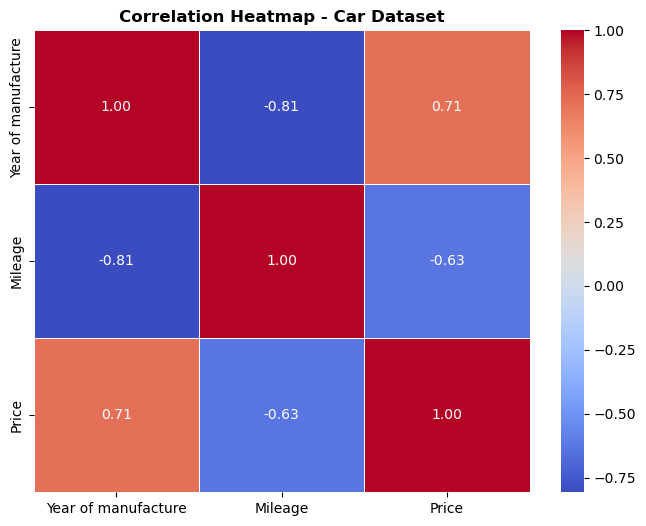

In [736]:
# Select numerical columns for correlation
corr = df[columns].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap - Car Dataset", weight="bold")
plt.show()

## Task 2: Comparison of visualisation of dimensionality reduction techniques

1) Compute different dimension reduction techniques on the dataset.

2) Visualise the results of each method in a single figure with n subplots, where each subplot shows the reduced dimensions in a 2D scatter plot.

3) Provide observations about how each technique reveals different aspects of the data.

In [738]:
# Task 2: Dimensionality Reduction & Visualization

# Use preprocessed dataset
X = df.copy()
print("✅ Using preprocessed dataset for dimensionality reduction\n")

# 1) PCA
pca = PCA(n_components=2).fit_transform(X)

# 2) t-SNE
tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=42).fit_transform(X)

# 3) UMAP
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(X)


✅ Using preprocessed dataset for dimensionality reduction



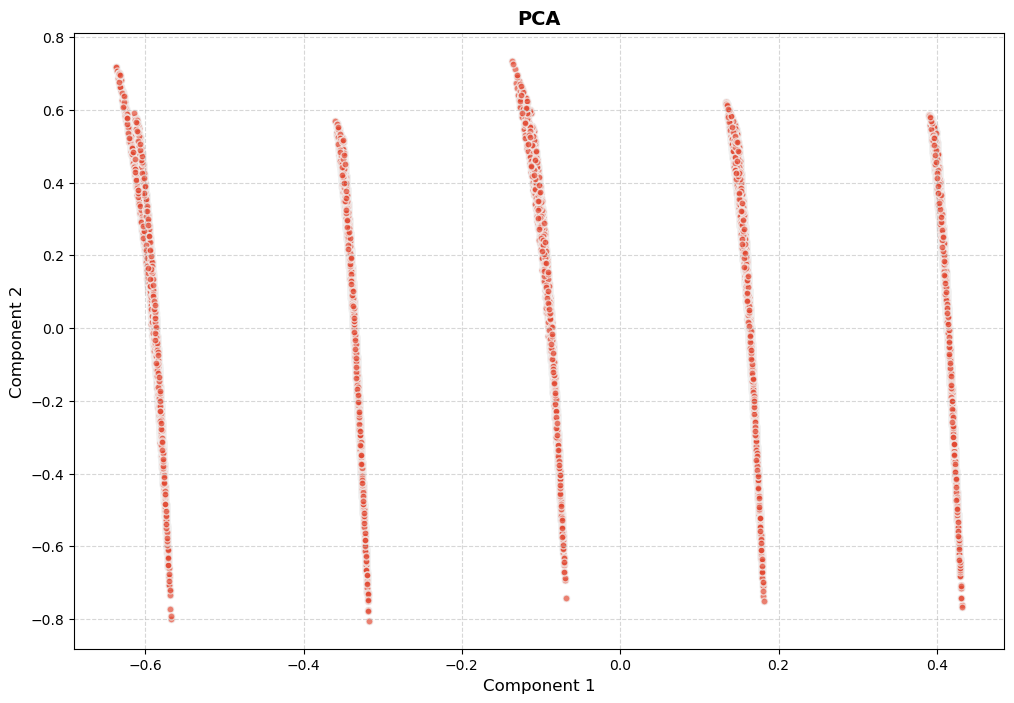

In [739]:
# 1) PCA
# ----------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(pca_result[:, 0], pca_result[:, 1], c='#E24A33', edgecolor='#f2f2f2', alpha=0.7, s=25)
ax.set_title('PCA', fontsize=14, fontweight='bold')
ax.set_xlabel('Component 1', fontsize=12)
ax.set_ylabel('Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

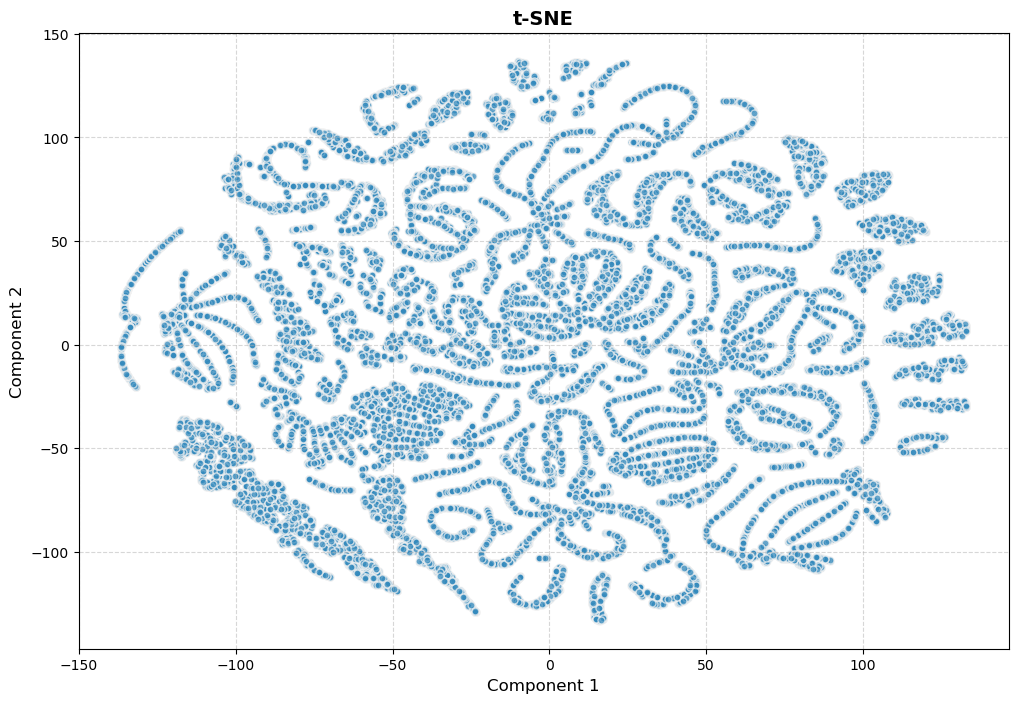

In [740]:
# 2) t-SNE
tsne = TSNE(n_components=2, init='random', learning_rate='auto', random_state=42)
tsne_result = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(tsne_result[:, 0], tsne_result[:, 1], c='#348ABD', edgecolor='#f2f2f2', alpha=0.7, s=25)
ax.set_title('t-SNE', fontsize=14, fontweight='bold')
ax.set_xlabel('Component 1', fontsize=12)
ax.set_ylabel('Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

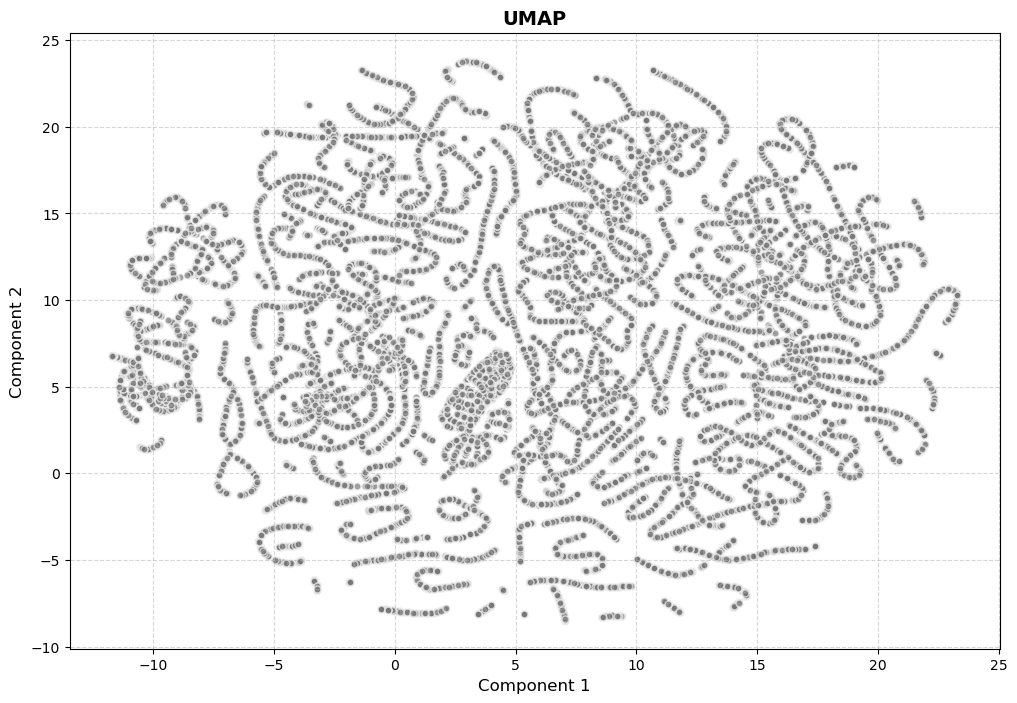

In [776]:
# 3) UMAP
# ----------------------------
umap_model = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_result = umap_model.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(umap_result[:, 0], umap_result[:, 1], c='#777777', edgecolor='#f2f2f2', alpha=0.7, s=25)
ax.set_title('UMAP', fontsize=14, fontweight='bold')
ax.set_xlabel('Component 1', fontsize=12)
ax.set_ylabel('Component 2', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Observations on Dimensionality Reduction:

#### 1) PCA:
- Captures the maximum variance in the first two components.
- Reveals linear patterns and highlights global structure of data.
- Good for seeing overall distribution, but may not separate clusters clearly.

#### 2) t-SNE:
- Preserves local structure and reveals clusters effectively.
- Points that are close in high-dimensional space remain close in 2D.
- Computationally intensive and sensitive to hyperparameters (perplexity, learning rate).

#### 3) UMAP:
- Preserves both local and some global structures.
- Often produces more meaningful clusters than t-SNE, and faster.
- Good for visualizing complex relationships in data.

#### Conclusion:
- PCA is suitable for global variance analysis.
- t-SNE and UMAP are better for identifying clusters and complex patterns.
- For tasks like clustering or anomaly detection, t-SNE/UMAP are preferred.

## Task 3: Model interpretability

Train a machine learning classifier and visualise its performance. Analyse and interpret the impact of each feature.

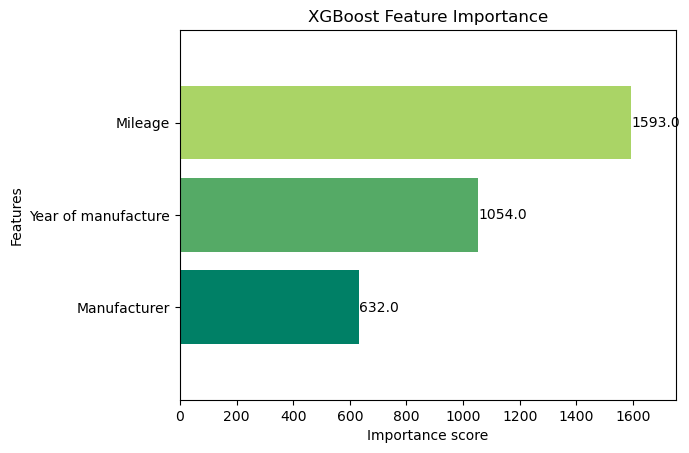

In [744]:
# Task 3: Model Interpretability

# Use preprocessed dataset from Task 1
# X = all features except Price, y = binary target (expensive vs cheap)
X = df.drop(columns=['Price'])
y = (df['Price'] > df['Price'].median()).astype(int)  # 1 = expensive, 0 = cheap

# 1) XGBoost Classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = xgb.XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

# Feature importance
ax = xgb.plot_importance(
    xgb_model,
    importance_type='weight',
    max_num_features=len(X.columns),
    title='XGBoost Feature Importance',
    height=0.8,
    show_values=True
)

for i, patch in enumerate(ax.patches):
    patch.set_facecolor(plt.cm.summer(i / len(ax.patches)))

ax.set_yticklabels([col.replace('_', ' ').capitalize() for col in X.columns])
plt.grid(False)
plt.show()

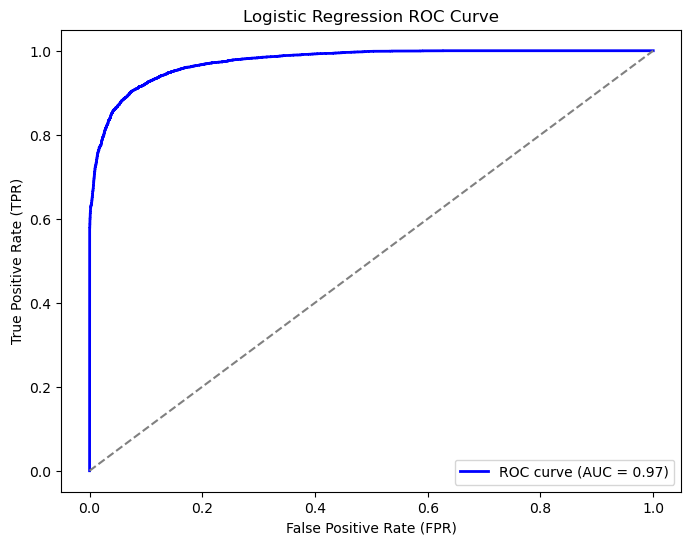

In [745]:
# 2) Logistic Regression + ROC Curve

# Use all features for simplicity
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
log_clf = LogisticRegression(max_iter=200)
log_clf.fit(X_train, y_train)

y_score = log_clf.predict_proba(X_test)[:, 1]  # probability of class 1
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid(False)
plt.show()

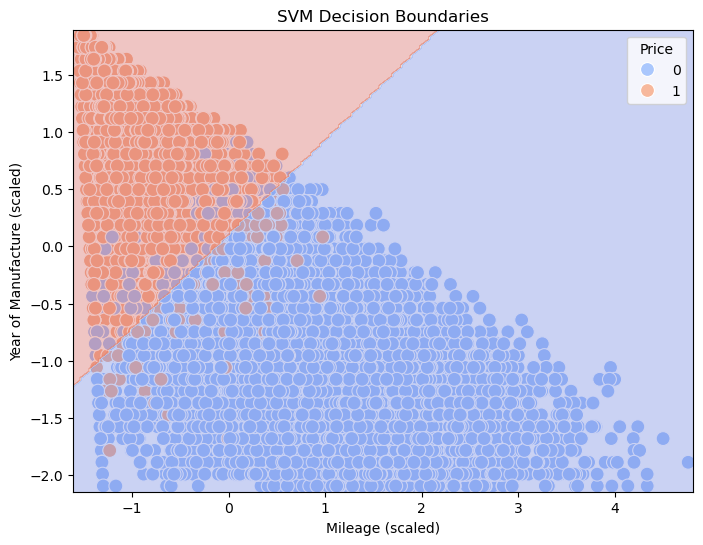

In [769]:
# 3) SVM Decision Boundaries

# For visualization, select 2 features: 'Mileage' and 'Year of manufacture'
X_svm = df[['Mileage', 'Year of manufacture']].copy()
y_svm = y

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svm)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_svm, test_size=0.3, random_state=42)

svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

# Meshgrid for decision boundary
x_min, x_max = X_train[:, 0].min() - 0.05, X_train[:, 0].max() + 0.05
y_min, y_max = X_train[:, 1].min() - 0.05, X_train[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = svm_clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1], hue=y_train, palette='coolwarm', s=100)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.title("SVM Decision Boundaries")
plt.xlabel("Mileage (scaled)")
plt.ylabel("Year of Manufacture (scaled)")
plt.grid(False)
plt.show()

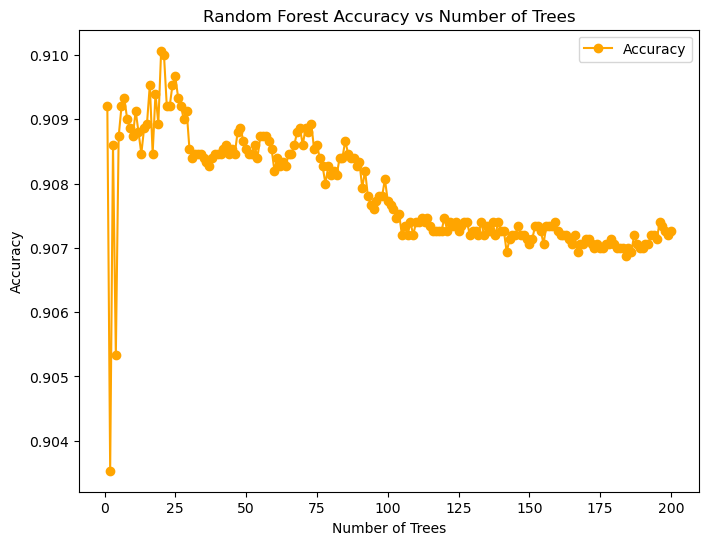

In [774]:
# 4) Random Forest Accuracy vs Number of Trees

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
n_estimators_range = range(1, 201)
accuracies = []

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(8, 6))
plt.plot(n_estimators_range, accuracies, marker='o', color='orange', label='Accuracy')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Accuracy vs Number of Trees")
plt.grid(False)
plt.legend()
plt.show()

## Task 4: Reflection

Answer the following reflection questions:

1) How does each dimensionality reduction technique differ?

2) Which technique provided the most interpretable results?

3) How did feature analysis help in understanding model predictions?


#### 1) How does each dimensionality reduction technique differ?

PCA (Principal Component Analysis) focuses on capturing the directions of maximum variance in the data. It’s linear, so it works well when the relationships between features are mostly linear. The resulting plot shows a clear spread along the principal components, but it may miss non-linear patterns.

t-SNE (t-distributed Stochastic Neighbor Embedding) is a non-linear technique that emphasizes local structure, meaning it keeps similar points close together. It’s great for visualizing clusters, but the axes don’t have a clear meaning, so interpretation is harder.

UMAP (Uniform Manifold Approximation and Projection) also captures non-linear relationships but balances local and global structure better than t-SNE. It often produces more meaningful clusters while preserving the overall data layout.

#### 2) Which technique provided the most interpretable results?

For this dataset, PCA was the most interpretable because the axes correspond to actual directions of variance in the features. You can see which patterns in the data are driving differences between cars. t-SNE and UMAP are great for visualization, but they’re less intuitive if you want to link the axes back to the original features.

#### 3) How did feature analysis help in understanding model predictions?

Feature analysis, like XGBoost feature importance and Random Forest evaluation, showed which factors influenced car prices the most. For example, Mileage and Year of Manufacture were consistently the top contributors. This helps us understand not just how the model performs, but why it makes certain predictions, giving insight into which car characteristics drive higher prices and making the model more transparent.

### Worksheets should be submitted on Canvas by the Monday after the lab at 23:59.